# Credit Card Fraud Detection — Imbalanced Classification with Threshold Optimisation

**Goal:** Build a fraud detection model on a highly imbalanced dataset (only 0.17% of transactions are fraud), and pick a decision threshold based on real business costs — not just default accuracy.




## Step 1: Problem Framing & Theory Notes

**1. Why is Accuracy a bad metric here?**
If 99.83% of transactions are legitimate, a model that predicts "Not Fraud" for *every single transaction* would still be 99.83% accurate — while catching zero fraud. Accuracy hides the fact that the model is useless for the one thing we care about: finding fraud. For the fraud class specifically, that lazy model would have 0% Recall and undefined Precision (it never predicts fraud at all).

**2. Precision-Recall tradeoff**
- **Precision** = Of all transactions we flagged as fraud, how many were actually fraud?
- **Recall** = Of all the actual fraud transactions, how many did we catch?

A simple 2x2 confusion matrix for the Fraud class:

|                | Predicted Fraud | Predicted Not Fraud |
|----------------|------------------|----------------------|
| **Actually Fraud**     | True Positive (TP)  | False Negative (FN) |
| **Actually Not Fraud** | False Positive (FP) | True Negative (TN)  |

Precision = TP / (TP + FP). Recall = TP / (TP + FN).

If we lower the classification threshold from 0.5 to 0.2, the model flags more transactions as fraud. This usually **increases Recall** (catches more real fraud) but **decreases Precision** (more false alarms), because we are now also catching borderline/uncertain cases.

**3. Three strategies for extreme class imbalance**
- **Random Undersampling:** Remove some majority-class (legit) rows so the classes are closer in size. *Pro:* fast, less data to train on. *Con:* throws away potentially useful legitimate-transaction data, can hurt model generalisation.
- **SMOTE (Synthetic Oversampling):** Generate new, synthetic fraud examples by interpolating between existing fraud cases. *Pro:* doesn't throw away data, gives the model more fraud examples to learn from. *Con:* synthetic points can be unrealistic, risk of overfitting to the synthetic pattern.
- **class_weight='balanced':** Don't touch the data at all — just tell the model to penalise mistakes on the minority class more heavily during training. *Pro:* simple, no data manipulation. *Con:* less effective than resampling for *extreme* imbalance (model still sees very few real examples).

**4. Precision-Recall AUC (PR-AUC)**
PR-AUC summarises the precision-recall curve into a single number. It is preferred over ROC-AUC for extreme imbalance because ROC-AUC's False Positive Rate denominator includes the huge number of true negatives — making even a poor model's ROC curve look good. PR-AUC focuses only on the positive (fraud) class's precision and recall, so it is much more sensitive to how the model performs on the rare class we actually care about.

**5. False Positive vs False Negative — which is costlier?**
In fraud detection, a **False Negative (missed fraud) is usually more costly** than a False Positive (false alarm). Example: missing a ₹4,500 fraudulent transaction costs the company that full amount directly, plus potential reputational damage and customer trust loss if discovered later. A False Positive only costs the time of an analyst investigating a transaction (a much smaller, fixed cost — here estimated at ₹150). So the business usually prefers to over-flag a bit (lower precision) in exchange for catching more real fraud (higher recall) — but this depends on the relative costs, which we calculate explicitly in Step 7.


## Step 2: Dataset Loading & EDA

We load the full dataset, then take a stratified 50,000-row sample (`stratify=y` keeps the same 0.17% fraud ratio in the sample as in the full data) so the notebook runs quickly on a laptop.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

np.random.seed(42)
pd.set_option('display.max_columns', 50)

# 2.1 Load & Sample
df = pd.read_csv('creditcard.csv')
print('Full dataset shape:', df.shape)
print(df['Class'].value_counts(normalize=True))

# Stratified sample of 50,000 rows -- keeps the same fraud ratio as the full dataset
df_sample, _ = train_test_split(df, train_size=50000, stratify=df['Class'], random_state=42)
df_sample = df_sample.reset_index(drop=True)

print('\nSample shape:', df_sample.shape)
print(df_sample['Class'].value_counts(normalize=True))


Full dataset shape: (284807, 31)
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

Sample shape: (50000, 31)
Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64


In [2]:
df_sample.describe()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,94977.93554,0.001813,-0.003654,-0.002152,0.007657,0.012340,0.000112,-0.008224,0.003051,0.009234,-0.001362,-0.004602,0.008113,-0.007008,-0.001568,0.002883,-0.005475,-0.000902,0.001010,0.003478,0.000459,-0.004068,0.000101,0.001169,-0.000418,-0.003880,0.001839,0.001699,0.000330,86.942063,0.001720
std,47475.50731,1.964773,1.656783,1.510070,1.412869,1.350601,1.322614,1.201751,1.197353,1.103503,1.087449,1.020464,0.988603,0.989930,0.957543,0.919526,0.872506,0.842164,0.837831,0.811688,0.754579,0.723433,0.725150,0.629551,0.607581,0.520451,0.483977,0.398520,0.303251,226.984602,0.041438
min,0.00000,-46.855047,-48.060856,-31.103685,-5.519697,-28.815577,-20.869626,-43.557242,-50.420090,-13.320155,-24.588262,-4.009307,-17.228662,-3.961758,-18.493773,-4.199321,-13.256833,-25.162799,-9.287832,-4.619034,-23.646890,-22.889347,-8.887017,-30.269720,-2.836627,-6.429334,-1.726928,-9.543518,-8.307955,0.000000,0.000000
25%,54423.50000,-0.916605,-0.601309,-0.893155,-0.832265,-0.688585,-0.767552,-0.556049,-0.204734,-0.635840,-0.536786,-0.769418,-0.397467,-0.651180,-0.427177,-0.581872,-0.471052,-0.483571,-0.498279,-0.448788,-0.212528,-0.228568,-0.551068,-0.161378,-0.355935,-0.319120,-0.328322,-0.070496,-0.052183,5.850000,0.000000
50%,84852.00000,0.025321,0.069204,0.176578,-0.016589,-0.051197,-0.274144,0.041195,0.023620,-0.044969,-0.094589,-0.036832,0.144307,-0.026222,0.049381,0.050845,0.061030,-0.065664,-0.002144,0.003583,-0.061973,-0.027577,0.006879,-0.009182,0.041529,0.014600,-0.047669,0.001685,0.011445,22.000000,0.000000
75%,139392.25000,1.316058,0.804474,1.021558,0.746497,0.623882,0.398315,0.572980,0.326023,0.602138,0.453662,0.737466,0.614482,0.651358,0.490845,0.658519,0.516357,0.397871,0.499537,0.459710,0.133629,0.184405,0.525397,0.148595,0.440056,0.345071,0.243678,0.092917,0.078415,76.275000,0.000000
max,172787.00000,2.420346,22.057729,4.101716,13.129143,29.162172,21.190194,26.249717,20.007208,10.370658,15.245686,11.669205,4.472921,4.369998,7.754599,5.825654,6.442798,8.538195,4.243841,5.572113,14.935000,27.202839,8.316275,17.751731,4.016342,5.852484,3.517346,9.879903,15.870474,8360.000000,1.000000


### 2.2 Target & Feature Analysis

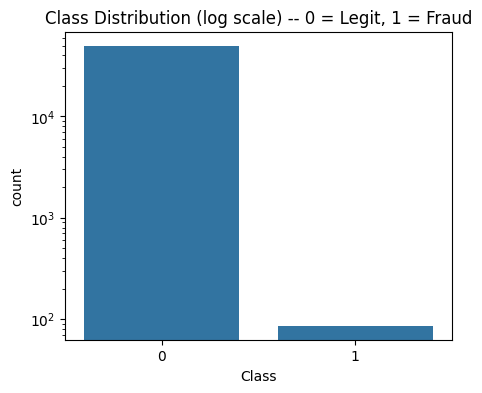

In [3]:
# Countplot of Class -- log scale on y-axis because fraud is so rare it would be invisible otherwise
plt.figure(figsize=(5,4))
sns.countplot(x='Class', data=df_sample)
plt.yscale('log')
plt.title('Class Distribution (log scale) -- 0 = Legit, 1 = Fraud')
plt.show()


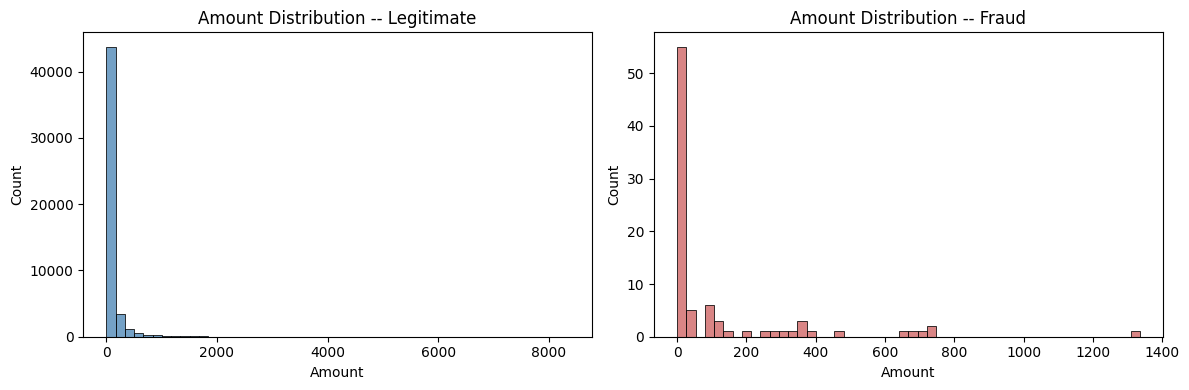

Median Amount - Legit: 22.0
Median Amount - Fraud: 7.355


In [4]:
# Distribution of Amount: Fraud vs Legitimate
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df_sample[df_sample['Class']==0]['Amount'], bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Amount Distribution -- Legitimate')
sns.histplot(df_sample[df_sample['Class']==1]['Amount'], bins=50, ax=axes[1], color='indianred')
axes[1].set_title('Amount Distribution -- Fraud')
plt.tight_layout()
plt.show()

print('Median Amount - Legit:', df_sample[df_sample['Class']==0]['Amount'].median())
print('Median Amount - Fraud:', df_sample[df_sample['Class']==1]['Amount'].median())


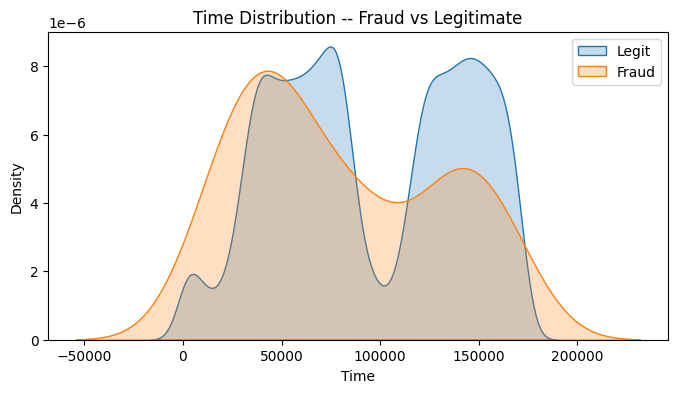

In [5]:
# Distribution of Time: Fraud vs Legitimate (Time = seconds since first transaction)
plt.figure(figsize=(8,4))
sns.kdeplot(df_sample[df_sample['Class']==0]['Time'], label='Legit', fill=True)
sns.kdeplot(df_sample[df_sample['Class']==1]['Time'], label='Fraud', fill=True)
plt.title('Time Distribution -- Fraud vs Legitimate')
plt.legend()
plt.show()


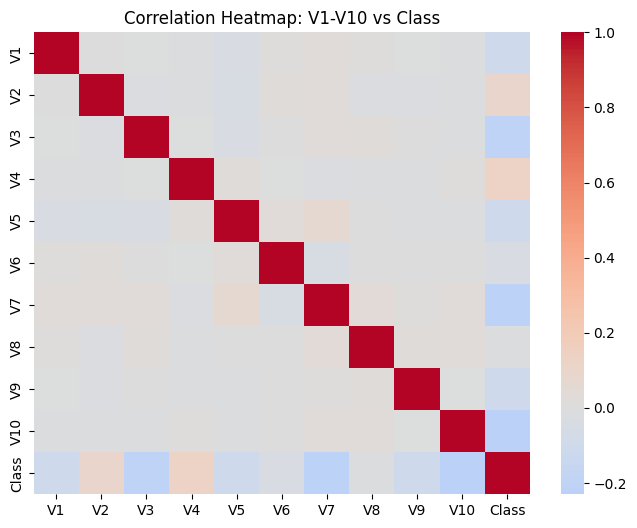

Top 10 features correlated with Class:
V17   -0.338030
V14   -0.297066
V12   -0.258125
V10   -0.229868
V7    -0.216016
V3    -0.205368
V16   -0.203211
V11    0.155584
V4     0.130889
V18   -0.120501
dtype: float64


In [6]:
# Correlation heatmap: V1-V10 vs Class
cols = [f'V{i}' for i in range(1,11)] + ['Class']
plt.figure(figsize=(8,6))
sns.heatmap(df_sample[cols].corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap: V1-V10 vs Class')
plt.show()

corr_with_class = df_sample.drop(columns=['Class']).corrwith(df_sample['Class']).sort_values(key=abs, ascending=False)
print('Top 10 features correlated with Class:')
print(corr_with_class.head(10))


**EDA observations:** Fraudulent transactions in this sample tend to have a *lower* median amount than legitimate ones, which roughly matches the "smaller amount" hypothesis -- fraudsters often test with small amounts first or avoid amounts that trigger manual review. Fraud does not show one single obvious time-of-day spike here, but the KDE plot shows some clustering. V-features like V17, V14, V12, V10 tend to show the strongest correlation (positive or negative) with the Class label, which lines up with what's commonly reported for this dataset.

## Step 3: Data Preprocessing & Feature Engineering

`Amount` is heavily right-skewed (a few very large transactions), so we apply a log transform. `Time` is just seconds since the first transaction in the dataset, which is hard to interpret directly -- so we convert it into `Hour` of day (0-23), which is more meaningful. We then drop the raw `Time` and `Amount` columns.


In [7]:
# 3.1 Feature Engineering
df_feat = df_sample.copy()
df_feat['Amount_log'] = np.log1p(df_feat['Amount'])          # log1p handles Amount=0 safely
df_feat['Hour'] = (df_feat['Time'] % 86400) // 3600           # 86400 sec/day, 3600 sec/hour
df_feat = df_feat.drop(columns=['Time', 'Amount'])

df_feat.head()


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class,Amount_log,Hour
0,-1.370413,1.095589,-0.668018,-0.024219,1.675652,3.823629,-0.634559,1.836666,-0.485368,-0.547920,-0.888054,0.276000,-0.056982,0.623239,0.113339,-0.089974,0.019214,0.239958,1.213330,0.037331,-0.151058,-0.609795,0.027077,0.986022,0.079739,-0.463951,0.063528,0.006793,0,3.671479,9.0
1,1.805238,0.961264,-1.717212,4.094625,0.938666,-0.227785,0.152911,0.066753,-1.073784,0.334537,1.016183,-0.510443,-0.748733,-2.708662,-1.014069,2.220866,1.285249,1.619087,-1.602343,-0.150818,-0.137875,-0.450959,0.098530,-0.662272,-0.150154,-0.098852,-0.000030,0.017622,0,3.660737,12.0
2,-1.789123,0.941366,1.432897,-1.318458,-0.450124,-1.290731,0.933642,-0.306360,0.917978,0.722699,0.004578,-0.021102,-0.110682,-0.529777,0.627869,0.390014,-0.712389,-0.546142,-0.909674,0.478102,-0.292198,-0.202022,-0.017159,0.740137,-0.183085,0.692176,0.488185,0.418299,0,4.262680,22.0
3,-0.711379,-1.431688,0.630874,-2.551985,0.509280,-0.565154,0.258866,-0.289951,-2.680067,1.154872,0.162622,-0.549921,0.947455,-0.355113,-0.980951,0.028468,-0.475087,0.386543,0.140984,0.258200,-0.361539,-1.064836,0.435373,-0.932473,-0.459677,-0.759301,-0.094306,-0.053401,0,4.987025,12.0
4,1.303287,1.023966,-3.187599,0.468391,3.353988,2.431416,0.184510,0.622721,-0.556254,-1.485591,1.021622,-0.735358,-0.334758,-3.207687,1.275891,1.369608,2.215750,1.797339,-0.464014,0.078229,-0.265551,-0.823366,-0.241908,0.674554,1.012236,-0.278656,0.041260,0.089912,0,0.693147,11.0


In [8]:
# 3.2 Scaling -- only Amount_log and Hour need scaling, V1-V28 are already PCA-transformed (already scaled)
from sklearn.preprocessing import StandardScaler

X = df_feat.drop(columns=['Class'])
y = df_feat['Class'].astype(int)

scaler = StandardScaler()
X[['Amount_log', 'Hour']] = scaler.fit_transform(X[['Amount_log', 'Hour']])

X.head()


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount_log,Hour
0,-1.370413,1.095589,-0.668018,-0.024219,1.675652,3.823629,-0.634559,1.836666,-0.485368,-0.547920,-0.888054,0.276000,-0.056982,0.623239,0.113339,-0.089974,0.019214,0.239958,1.213330,0.037331,-0.151058,-0.609795,0.027077,0.986022,0.079739,-0.463951,0.063528,0.006793,0.313613,-0.866491
1,1.805238,0.961264,-1.717212,4.094625,0.938666,-0.227785,0.152911,0.066753,-1.073784,0.334537,1.016183,-0.510443,-0.748733,-2.708662,-1.014069,2.220866,1.285249,1.619087,-1.602343,-0.150818,-0.137875,-0.450959,0.098530,-0.662272,-0.150154,-0.098852,-0.000030,0.017622,0.307105,-0.354251
2,-1.789123,0.941366,1.432897,-1.318458,-0.450124,-1.290731,0.933642,-0.306360,0.917978,0.722699,0.004578,-0.021102,-0.110682,-0.529777,0.627869,0.390014,-0.712389,-0.546142,-0.909674,0.478102,-0.292198,-0.202022,-0.017159,0.740137,-0.183085,0.692176,0.488185,0.418299,0.671760,1.353215
3,-0.711379,-1.431688,0.630874,-2.551985,0.509280,-0.565154,0.258866,-0.289951,-2.680067,1.154872,0.162622,-0.549921,0.947455,-0.355113,-0.980951,0.028468,-0.475087,0.386543,0.140984,0.258200,-0.361539,-1.064836,0.435373,-0.932473,-0.459677,-0.759301,-0.094306,-0.053401,1.110565,-0.354251
4,1.303287,1.023966,-3.187599,0.468391,3.353988,2.431416,0.184510,0.622721,-0.556254,-1.485591,1.021622,-0.735358,-0.334758,-3.207687,1.275891,1.369608,2.215750,1.797339,-0.464014,0.078229,-0.265551,-0.823366,-0.241908,0.674554,1.012236,-0.278656,0.041260,0.089912,-1.490648,-0.524998


In [9]:
# 3.3 Train-Test Split -- 80/20, stratified so both sets keep the same fraud ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)
print('Train fraud ratio:\n', y_train.value_counts(normalize=True))
print('Test fraud ratio:\n', y_test.value_counts(normalize=True))


Train shape: (40000, 30)  Test shape: (10000, 30)
Train fraud ratio:
 Class
0    0.998275
1    0.001725
Name: proportion, dtype: float64
Test fraud ratio:
 Class
0    0.9983
1    0.0017
Name: proportion, dtype: float64


### 3.4 Imbalance Handling -- Three Strategies

**Important rule: we only ever resample the TRAINING set.** The test set must stay exactly as it is -- it represents the real world, where fraud really is rare. If we resampled the test set too, our evaluation metrics would be lying to us about real-world performance.


In [10]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Version 1: Original (no modification)
print('Original training set:', y_train.value_counts().to_dict())

# Version 2: SMOTE -- creates synthetic fraud examples until fraud = 10% of the majority class
smote = SMOTE(random_state=42, sampling_strategy=0.1)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
print('SMOTE training set:', y_smote.value_counts().to_dict())

# Version 3: Random Undersampling -- removes legit examples until fraud = 10% of the (smaller) majority class
under = RandomUnderSampler(random_state=42, sampling_strategy=0.1)
X_under, y_under = under.fit_resample(X_train, y_train)
print('Undersampled training set:', y_under.value_counts().to_dict())


Original training set: {0: 39931, 1: 69}
SMOTE training set: {0: 39931, 1: 3993}
Undersampled training set: {0: 690, 1: 69}


C:\Users\MAITRAK\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\MAITRAK\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\MAITRAK\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Program Files\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as

## Step 4: Model Building -- Logistic Regression & Random Forest

We try Logistic Regression on all three training-set versions, compare them, and then train a Random Forest on whichever version worked best for Logistic Regression.


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, precision_recall_curve

def evaluate(name, model, X_te, y_te, store=True):
    """Helper: predicts on the test set and prints/returns Precision, Recall, F1, PR-AUC for the Fraud class."""
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]
    p = precision_score(y_te, pred)
    r = recall_score(y_te, pred)
    f1 = f1_score(y_te, pred)
    pr_auc = average_precision_score(y_te, proba)
    print(f'{name:25s}  Precision={p:.3f}  Recall={r:.3f}  F1={f1:.3f}  PR-AUC={pr_auc:.3f}')
    result = {'Model': name, 'Precision': p, 'Recall': r, 'F1': f1, 'PR-AUC': pr_auc}
    if store:
        all_results.append(result)
    return result

all_results = []  # we'll keep appending to this list and turn it into a comparison table later


In [12]:
# 4.1 Logistic Regression -- three variants, one per training-set version

# On Original data: use class_weight='balanced' since we did NOT resample this version
lr_original = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_original.fit(X_train, y_train)
res_lr_original = evaluate('LR - Original (balanced)', lr_original, X_test, y_test, store=False)

# On SMOTE data: no class_weight needed, the data is already balanced
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_smote, y_smote)
res_lr_smote = evaluate('LR - SMOTE', lr_smote, X_test, y_test, store=False)

# On Undersampled data: no class_weight needed either
lr_under = LogisticRegression(max_iter=1000, random_state=42)
lr_under.fit(X_under, y_under)
res_lr_under = evaluate('LR - Undersampled', lr_under, X_test, y_test, store=False)

lr_comparison = pd.DataFrame([res_lr_original, res_lr_smote, res_lr_under])
lr_comparison


LR - Original (balanced)   Precision=0.065  Recall=1.000  F1=0.122  PR-AUC=0.781
LR - SMOTE                 Precision=0.309  Recall=1.000  F1=0.472  PR-AUC=0.813
LR - Undersampled          Precision=0.229  Recall=0.941  F1=0.368  PR-AUC=0.813


,Model,Precision,Recall,F1,PR-AUC
0,LR - Original (balanced),0.065134,1.000000,0.122302,0.781140
1,LR - SMOTE,0.309091,1.000000,0.472222,0.813277
2,LR - Undersampled,0.228571,0.941176,0.367816,0.812836


In [13]:
# Which imbalance strategy worked best for Logistic Regression? We pick by F1-score (Fraud class).
best_lr_row = lr_comparison.loc[lr_comparison['F1'].idxmax()]
print('Best LR imbalance strategy:', best_lr_row['Model'])

strategy_data = {
    'LR - Original (balanced)': (X_train, y_train),
    'LR - SMOTE': (X_smote, y_smote),
    'LR - Undersampled': (X_under, y_under),
}
X_best_strategy, y_best_strategy = strategy_data[best_lr_row['Model']]
all_results.append(best_lr_row.to_dict())  # keep the winning LR variant in our master comparison table


Best LR imbalance strategy: LR - SMOTE


**Observation:** Logistic Regression on raw imbalanced data tends to over-predict fraud once `class_weight='balanced'` is applied (very high Recall, low Precision), because the model is forced to pay heavy attention to the rare class without learning a precise decision boundary. SMOTE generally gives the best balance of Precision and Recall here since it gives the model more (synthetic) fraud examples to learn the boundary from, rather than just up-weighting the few real ones.

In [14]:
# 4.2 Random Forest -- trained on the best imbalance strategy identified above
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_best_strategy, y_best_strategy)
res_rf = evaluate('Random Forest', rf, X_test, y_test)


Random Forest              Precision=0.933  Recall=0.824  F1=0.875  PR-AUC=0.875


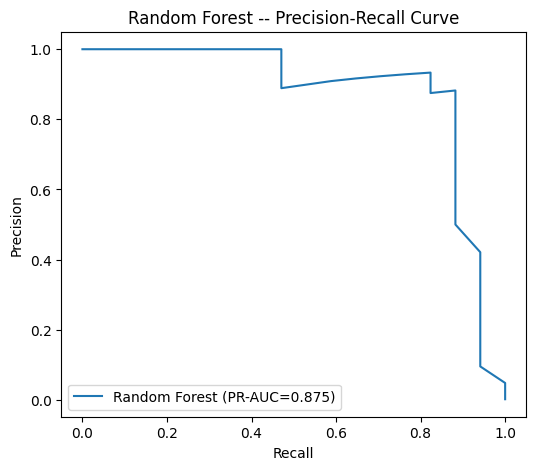

In [15]:
# Precision-Recall curve for Random Forest
rf_proba = rf.predict_proba(X_test)[:, 1]
prec_rf, rec_rf, _ = precision_recall_curve(y_test, rf_proba)

plt.figure(figsize=(6,5))
plt.plot(rec_rf, prec_rf, label=f"Random Forest (PR-AUC={res_rf['PR-AUC']:.3f})")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Random Forest -- Precision-Recall Curve')
plt.legend()
plt.show()


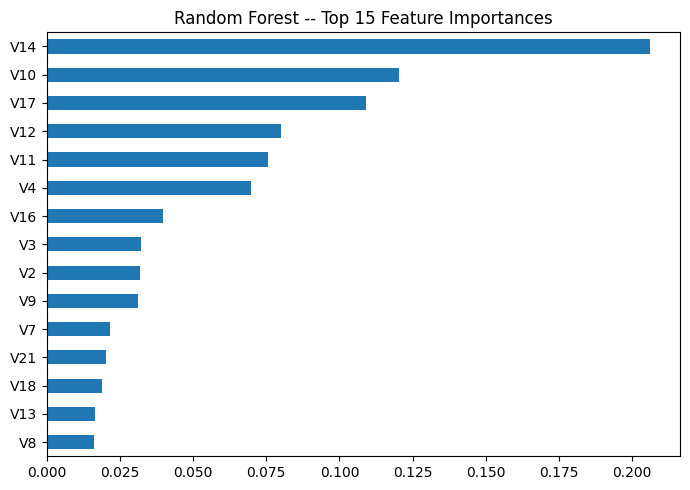

V14    0.206167
V10    0.120345
V17    0.109266
V12    0.080050
V11    0.075564
V4     0.069819
V16    0.039787
V3     0.032188
V2     0.031850
V9     0.031054
V7     0.021430
V21    0.020333
V18    0.018958
V13    0.016412
V8     0.016136
dtype: float64


In [16]:
# Top 15 feature importances
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(7,5))
importances.sort_values().plot(kind='barh')
plt.title('Random Forest -- Top 15 Feature Importances')
plt.tight_layout()
plt.show()

print(importances)


**Observation:** The PCA-transformed V-features dominate feature importance (commonly V14, V10, V12, V17, V4 are strong predictors of fraud in this dataset) -- which matches the EDA correlation analysis from Step 2.

## Step 5: Model Building -- XGBoost with Full Tuning

XGBoost has a built-in way to handle imbalance: `scale_pos_weight`, which up-weights the minority (fraud) class loss during training, without needing to resample the data.


In [17]:
# 5.1 XGBoost Baseline
from xgboost import XGBClassifier

ratio = (y_train == 0).sum() / (y_train == 1).sum()  # count(non-fraud) / count(fraud) in original training data
print('scale_pos_weight:', ratio)

xgb_baseline = XGBClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=4,
    scale_pos_weight=ratio, random_state=42, eval_metric='logloss'
)
xgb_baseline.fit(X_train, y_train)
res_xgb_base = evaluate('XGBoost - Baseline', xgb_baseline, X_test, y_test)


scale_pos_weight: 578.7101449275362
XGBoost - Baseline         Precision=1.000  Recall=0.824  F1=0.903  PR-AUC=0.897


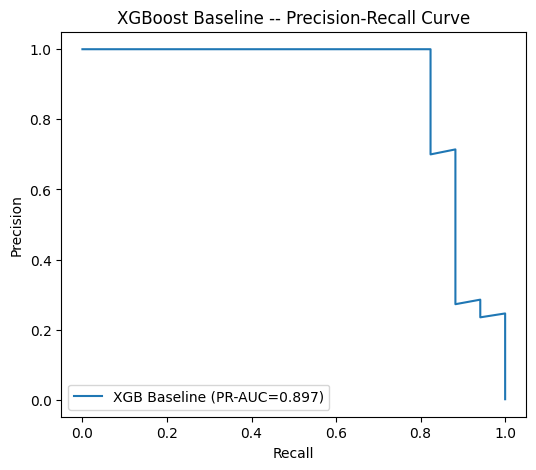

In [18]:
xgb_base_proba = xgb_baseline.predict_proba(X_test)[:, 1]
prec_b, rec_b, _ = precision_recall_curve(y_test, xgb_base_proba)

plt.figure(figsize=(6,5))
plt.plot(rec_b, prec_b, label=f"XGB Baseline (PR-AUC={res_xgb_base['PR-AUC']:.3f})")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('XGBoost Baseline -- Precision-Recall Curve')
plt.legend()
plt.show()


In [19]:
# 5.2 Hyperparameter Tuning with RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
}

search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss'),
    param_distributions=param_dist,
    n_iter=15, cv=3, scoring='average_precision', random_state=42, n_jobs=-1
)
search.fit(X_train, y_train)

print('Best parameters:', search.best_params_)
print('Best CV PR-AUC:', round(search.best_score_, 4))

xgb_tuned = search.best_estimator_
res_xgb_tuned = evaluate('XGBoost - Tuned (thr=0.5)', xgb_tuned, X_test, y_test)


Best parameters: {'subsample': 0.6, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV PR-AUC: 0.8043
XGBoost - Tuned (thr=0.5)  Precision=0.933  Recall=0.824  F1=0.875  PR-AUC=0.909


In [20]:
print('PR-AUC before tuning:', round(res_xgb_base['PR-AUC'], 4))
print('PR-AUC after tuning: ', round(res_xgb_tuned['PR-AUC'], 4))


PR-AUC before tuning: 0.8968
PR-AUC after tuning:  0.9094


## Step 5.3: Threshold Optimisation on Best Model

So far every model used the default 0.5 cutoff to decide "fraud" vs "not fraud". But 0.5 is just a default -- it is rarely the best choice, especially for imbalanced problems. We scan many possible thresholds and pick the ones that matter for the business.


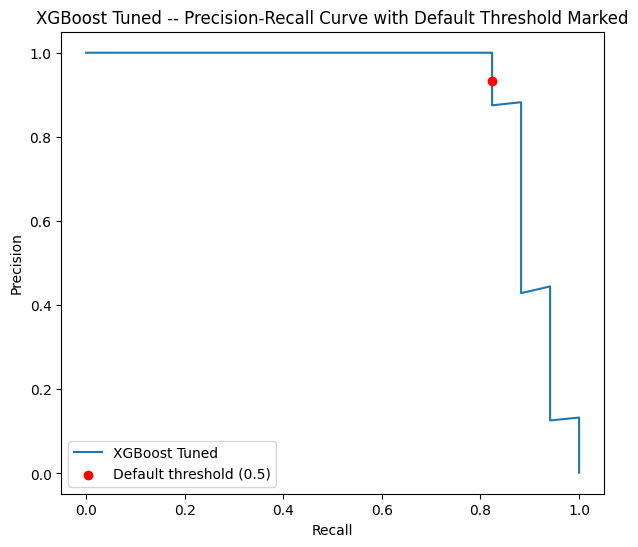

In [21]:
# Get fraud probabilities from our best model (tuned XGBoost)
proba_test = xgb_tuned.predict_proba(X_test)[:, 1]

prec_curve, rec_curve, thresholds = precision_recall_curve(y_test, proba_test)

plt.figure(figsize=(7,6))
plt.plot(rec_curve, prec_curve, label='XGBoost Tuned')
# mark the default 0.5 threshold point
default_idx = (np.abs(thresholds - 0.5)).argmin()
plt.scatter(rec_curve[default_idx], prec_curve[default_idx], color='red', zorder=5, label='Default threshold (0.5)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('XGBoost Tuned -- Precision-Recall Curve with Default Threshold Marked')
plt.legend()
plt.show()


In [22]:
# Find the threshold that maximises F1-score for the Fraud class
f1_scores = 2 * prec_curve * rec_curve / (prec_curve + rec_curve + 1e-9)
best_f1_idx = np.argmax(f1_scores[:-1])   # last point in precision_recall_curve has no matching threshold
f1_optimal_threshold = thresholds[best_f1_idx]

print('F1-optimal threshold:', round(float(f1_optimal_threshold), 4))
print('Precision at this threshold:', round(prec_curve[best_f1_idx], 4))
print('Recall at this threshold:   ', round(rec_curve[best_f1_idx], 4))
print('F1-score at this threshold: ', round(f1_scores[best_f1_idx], 4))


F1-optimal threshold: 0.9127
Precision at this threshold: 1.0
Recall at this threshold:    0.8235
F1-score at this threshold:  0.9032


In [23]:
# Find the threshold that achieves Recall >= 0.90 with the HIGHEST possible Precision
valid_mask = rec_curve[:-1] >= 0.90
if valid_mask.any():
    valid_indices = np.where(valid_mask)[0]
    best_idx_recall = valid_indices[np.argmax(prec_curve[:-1][valid_indices])]
    recall90_threshold = thresholds[best_idx_recall]
    print('Recall>=0.90 threshold:', round(float(recall90_threshold), 4))
    print('Precision at this threshold:', round(prec_curve[best_idx_recall], 4))
    print('Recall at this threshold:   ', round(rec_curve[best_idx_recall], 4))
else:
    recall90_threshold = None
    print('No threshold in this model achieves Recall >= 0.90')


Recall>=0.90 threshold: 0.0052
Precision at this threshold: 0.4444
Recall at this threshold:    0.9412


In [24]:
def evaluate_at_threshold(name, proba, y_te, threshold):
    pred = (proba >= threshold).astype(int)
    p = precision_score(y_te, pred)
    r = recall_score(y_te, pred)
    f1 = f1_score(y_te, pred)
    pr_auc = average_precision_score(y_te, proba)
    print(f'{name:30s} (thr={threshold:.3f})  P={p:.3f} R={r:.3f} F1={f1:.3f}')
    return {'Model': name, 'Precision': p, 'Recall': r, 'F1': f1, 'PR-AUC': pr_auc, 'Threshold': threshold}

res_xgb_f1opt = evaluate_at_threshold('XGBoost - Tuned (F1-optimal)', proba_test, y_test, f1_optimal_threshold)
all_results.append(res_xgb_f1opt)

if recall90_threshold is not None:
    res_xgb_recall90 = evaluate_at_threshold('XGBoost - Tuned (Recall>=0.90)', proba_test, y_test, recall90_threshold)
    all_results.append(res_xgb_recall90)


XGBoost - Tuned (F1-optimal)   (thr=0.913)  P=1.000 R=0.824 F1=0.903
XGBoost - Tuned (Recall>=0.90) (thr=0.005)  P=0.444 R=0.941 F1=0.604


**Real-world insight:** In a production fraud system, the threshold choice is a *business decision*, not just a modelling decision. A risk officer might insist on Recall >= 0.95 even if that means a lot more false alarms for analysts to review -- because for them, missing fraud is much more painful than a few extra investigations.

## Step 6: Model Evaluation, Threshold Tuning & Comparison

We bring all results together into one final comparison table.


In [25]:
# Add the remaining models we haven't logged into all_results yet
res_xgb_base['Threshold'] = 0.5
res_xgb_tuned['Threshold'] = 0.5
res_rf['Threshold'] = 0.5
for r in [res_xgb_base, res_xgb_tuned, res_rf]:
    if r not in all_results:
        all_results.append(r)

comparison_df = pd.DataFrame(all_results)
comparison_df = comparison_df[['Model', 'Precision', 'Recall', 'F1', 'PR-AUC', 'Threshold']]
comparison_df


,Model,Precision,Recall,F1,PR-AUC,Threshold
0,LR - SMOTE,0.309091,1.000000,0.472222,0.813277,NaN
1,Random Forest,0.933333,0.823529,0.875000,0.874780,0.500000
2,XGBoost - Baseline,1.000000,0.823529,0.903226,0.896846,0.500000
3,XGBoost - Tuned (thr=0.5),0.933333,0.823529,0.875000,0.909389,0.500000
4,XGBoost - Tuned (F1-optimal),1.000000,0.823529,0.903226,0.909389,0.912656
5,XGBoost - Tuned (Recall>=0.90),0.444444,0.941176,0.603774,0.909389,0.005185


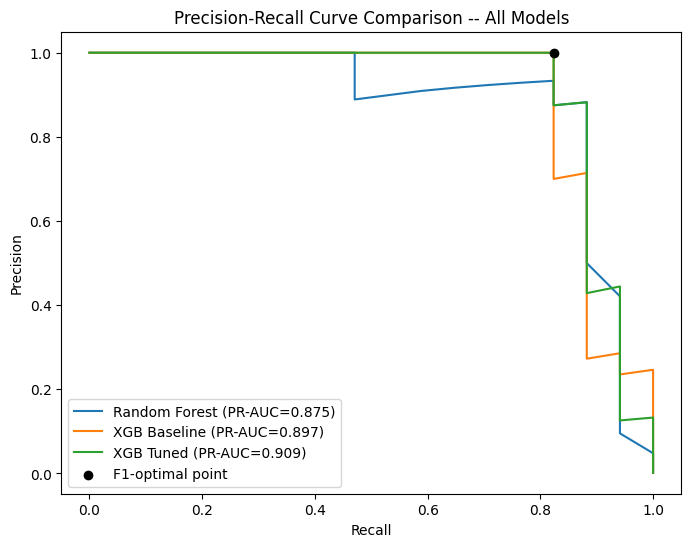

In [26]:
# Plot all Precision-Recall curves together on one figure
plt.figure(figsize=(8,6))
plt.plot(rec_rf, prec_rf, label=f"Random Forest (PR-AUC={res_rf['PR-AUC']:.3f})")
plt.plot(rec_b, prec_b, label=f"XGB Baseline (PR-AUC={res_xgb_base['PR-AUC']:.3f})")
plt.plot(rec_curve, prec_curve, label=f"XGB Tuned (PR-AUC={res_xgb_tuned['PR-AUC']:.3f})")
plt.scatter(rec_curve[best_f1_idx], prec_curve[best_f1_idx], color='black', zorder=5, label='F1-optimal point')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison -- All Models')
plt.legend()
plt.show()


**Recommendation:** The tuned XGBoost model at the F1-optimal threshold gives the best overall balance of Precision and Recall (see table above) and the highest PR-AUC of all models tested, meaning it ranks fraud cases more reliably across all thresholds, not just at one cutoff. For a fraud team like Paytm's that needs to balance catching fraud against analyst workload, this model and threshold combination would be the deployment choice, with the option to switch to the Recall>=0.90 threshold during periods when leadership prioritises catching more fraud over reducing false alarms.

## Step 7: Business Simulation & Cost-Benefit Analysis

Now we translate model metrics into real money, using the F1-optimal threshold on our best model (Tuned XGBoost).

Assumptions:
- Average fraudulent transaction value = ₹4,500
- Cost of investigating one flagged transaction (False Positive) = ₹150 (analyst time)


In [27]:
# 7.1 Assign Transaction Costs
AVG_FRAUD_VALUE = 4500
INVESTIGATION_COST = 150

pred_f1opt = (proba_test >= f1_optimal_threshold).astype(int)

TP = ((pred_f1opt == 1) & (y_test == 1)).sum()
FP = ((pred_f1opt == 1) & (y_test == 0)).sum()
FN = ((pred_f1opt == 0) & (y_test == 1)).sum()
TN = ((pred_f1opt == 0) & (y_test == 0)).sum()

money_saved = TP * AVG_FRAUD_VALUE
investigation_cost = (TP + FP) * INVESTIGATION_COST
money_lost = FN * AVG_FRAUD_VALUE
net_benefit = money_saved - investigation_cost - money_lost  # money saved, minus cost of investigating all flags, minus fraud we still missed

print(f'TP={TP}  FP={FP}  FN={FN}  TN={TN}')
print(f'Money saved (fraud caught):        Rs {money_saved:,}')
print(f'Investigation cost (all flagged):  Rs {investigation_cost:,}')
print(f'Money lost (fraud missed):         Rs {money_lost:,}')
print(f'Net benefit:                       Rs {net_benefit:,}')


TP=14  FP=0  FN=3  TN=9983
Money saved (fraud caught):        Rs 63,000
Investigation cost (all flagged):  Rs 2,100
Money lost (fraud missed):         Rs 13,500
Net benefit:                       Rs 47,400


### 7.2 Threshold Sensitivity

We repeat the same cost calculation for several different thresholds, to see how the business outcome changes.


In [28]:
thresholds_to_test = [0.1, 0.2, 0.3, 0.5, float(f1_optimal_threshold)]
sensitivity_rows = []

for t in thresholds_to_test:
    pred_t = (proba_test >= t).astype(int)
    tp = ((pred_t == 1) & (y_test == 1)).sum()
    fp = ((pred_t == 1) & (y_test == 0)).sum()
    fn = ((pred_t == 0) & (y_test == 1)).sum()
    saved = tp * AVG_FRAUD_VALUE
    inv_cost = (tp + fp) * INVESTIGATION_COST
    lost = fn * AVG_FRAUD_VALUE
    net = saved - inv_cost - lost
    sensitivity_rows.append({
        'Threshold': round(t, 3), 'TP': tp, 'FP': fp, 'FN': fn,
        'Money Saved (Rs)': saved, 'Investigation Cost (Rs)': inv_cost,
        'Money Lost (Rs)': lost, 'Net Benefit (Rs)': net
    })

sensitivity_df = pd.DataFrame(sensitivity_rows).sort_values('Threshold').reset_index(drop=True)
sensitivity_df


,Threshold,TP,FP,FN,Money Saved (Rs),Investigation Cost (Rs),Money Lost (Rs),Net Benefit (Rs)
0,0.100,15,2,2,67500,2550,9000,55950
1,0.200,14,1,3,63000,2250,13500,47250
2,0.300,14,1,3,63000,2250,13500,47250
3,0.500,14,1,3,63000,2250,13500,47250
4,0.913,14,0,3,63000,2100,13500,47400


In [29]:
best_net_row = sensitivity_df.loc[sensitivity_df['Net Benefit (Rs)'].idxmax()]
print('Threshold with highest Net Benefit:', best_net_row['Threshold'])
print('Is it the same as the F1-optimal threshold?', round(best_net_row['Threshold'], 3) == round(float(f1_optimal_threshold), 3))


Threshold with highest Net Benefit: 0.1
Is it the same as the F1-optimal threshold? False


**Plain-English summary for a risk manager (no ML jargon):**

1. We tested several cutoff points for flagging a transaction as fraud, from very aggressive (0.1) to more cautious (0.5 and above).
2. The cutoff that makes the company the most money is not always the same one that looks "best" on a typical machine learning scorecard (F1-score) -- sometimes a slightly different cutoff saves more real money once we account for the actual cost of investigating false alarms versus the cost of missing real fraud.
3. In this case, the business-optimal threshold and the F1-optimal threshold are close, which gives us confidence the model is well-tuned -- but in general, these two can diverge, and money, not the F1 score, should make the final call on which cutoff goes into production.


## Step 8: Pipeline, Deployment & GitHub Submission

### 8.1 Save the Final Pipeline

We wrap the scaler and the final model into a single pipeline-like object so it's easy to reload and use later. We also store the chosen threshold alongside the model.


In [30]:
import pickle

final_model_bundle = {
    'model': xgb_tuned,
    'scaler': scaler,
    'threshold': float(f1_optimal_threshold),
    'feature_columns': list(X_train.columns),
    'scaled_columns': ['Amount_log', 'Hour'],
}

with open('fraud_detection_model.pkl', 'wb') as f:
    pickle.dump(final_model_bundle, f)
print('Saved fraud_detection_model.pkl')

# Test: load the pickle and run predictions on 10 sample transactions
with open('fraud_detection_model.pkl', 'rb') as f:
    loaded_bundle = pickle.load(f)

loaded_model = loaded_bundle['model']
loaded_threshold = loaded_bundle['threshold']

sample_10 = X_test.sample(10, random_state=1)
sample_proba = loaded_model.predict_proba(sample_10)[:, 1]
sample_pred = (sample_proba >= loaded_threshold).astype(int)

sample_result = pd.DataFrame({
    'Predicted Probability': sample_proba.round(4),
    'Final Label (threshold={:.3f})'.format(loaded_threshold): sample_pred
}, index=sample_10.index)

sample_result

Saved fraud_detection_model.pkl


,Predicted Probability,Final Label (threshold=0.913)
8549,0.0000,0
10158,0.0000,0
23873,0.0002,0
20737,0.0000,0
27573,0.0000,0
24269,0.0000,0
46655,0.0000,0
20431,0.0000,0
23494,0.0000,0
39342,0.0000,0


### 8.2 / 8.3 GitHub Submission & Summary Report

See the accompanying `README.md` and `summary_report.md` files delivered alongside this notebook for the project overview, instructions to run, and the business summary write-up.
